# Extract LFPs
## Understanding filtering artifacts and chunking when extracting LFPs
Local Field Potentials (LFPs) are low-frequency signals (<300 Hz) that reflect the summed activity of many neurons. Extracting LFPs from high-sampling-rate recordings requires bandpass filtering, but this can introduce artifacts when not done carefully, especially when data is processed in chunks (which is usually the required because datasets cannot be loaded entirely into memory).

Before we get started, let’s introduce some important concepts:

### Chunk
A “chunk” is a piece of recording that gets processed in parallel by SpikeInterface. The default chunk duration for most operations is 1 second, but we’ll see how this is not adequate for LFP processing.

### Margin
When we apply a filter on chunked data, we extract additional “margins” of traces at the chunk borders. This is done to reduce border artifacts.

This tutorial demonstrates:

1. How to generate simulated LFP data
2. Common pitfalls when filtering with low cutoff frequencies
3. How chunking and margins affect filtering artifacts
4. Summary

**Key takeaway**: For LFP extraction, use large chunks (30-60s) and large margins (several seconds) to minimize edge artifacts, even though this is less memory-efficient.

## Import necessary libraries

In [41]:
%matplotlib widget

import time
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import seaborn as sns

import spikeinterface as si
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
import spikeinterface.widgets as sw
from spikeinterface.core import generate_ground_truth_recording

print(f"Matplotlib backend: {mpl.get_backend()}")

Matplotlib backend: widget


## 1. Generate simulated recording with low-frequency signals

### Generate a ground truth recording with spikes 


In [42]:
# Use a higher sampling rate to simulate raw neural data
recording, sorting = generate_ground_truth_recording(
    durations=[60.0], 
    sampling_frequency=30000.0, 
    num_channels=1, 
    num_units=4,
    seed=2305,
)

print(recording)

GroundTruthRecording (InjectTemplatesRecording): 1 channels - 30.0kHz - 1 segments 
                      1,800,000 samples - 60.00s (1.00 minutes) - float32 dtype - 6.87 MiB


### Add low-frequency sinusoids with different frequencies and phases per channel to simulate LFP signals

In [43]:
rng = np.random.default_rng(seed=42)
num_channels = recording.get_num_channels()
lfp_signals = np.zeros(
    (recording.get_num_samples(), num_channels)
)
time_vector = recording.get_times()

for ch in range(num_channels):
    # Add multiple frequency components (theta, alpha, beta ranges)
    # Theta-like: 4-8 Hz
    freq_theta = 4 + rng.random() * 4
    phase_theta = rng.random() * 2 * np.pi
    amp_theta = 50 + rng.random() * 50

    # Alpha-like: 8-12 Hz
    freq_alpha = 8 + rng.random() * 4
    phase_alpha = rng.random() * 2 * np.pi
    amp_alpha = 30 + rng.random() * 30

    # Beta-like: 12-30 Hz
    freq_beta = 12 + rng.random() * 18
    phase_beta = rng.random() * 2 * np.pi
    amp_beta = 20 + rng.random() * 20

    # Generate the LFP signal for this channel
    lfp_signals[:, ch] = (
        amp_theta * np.sin(2 * np.pi * freq_theta * time_vector + phase_theta) +
        amp_alpha * np.sin(2 * np.pi * freq_alpha * time_vector + phase_alpha) +
        amp_beta * np.sin(2 * np.pi * freq_beta * time_vector + phase_beta)
    )

### Create a recording with the added LFP signals


In [44]:
recording_lfp = si.NumpyRecording(
    traces_list = [lfp_signals],
    sampling_frequency = recording.get_sampling_frequency(),
    channel_ids = recording.get_channel_ids()
)
recording_with_lfp = recording + recording_lfp

### Visualize a short segment of the signal

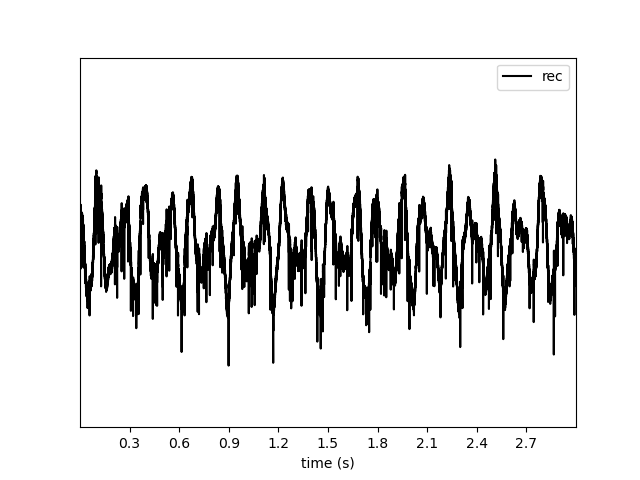

In [45]:
_ = sw.plot_traces(recording_with_lfp, time_range=[0,3])

## 2. Filtering with low cutoff frequencies : the problem

### Try to extract LFPs using a bandpass filter with a low highpass cutoff (1 Hz).
This will demonstrate a common issue

In [46]:
# Try to filter with 1 Hz highpass
try:
    recording_lfp_1hz = spre.bandpass_filter(
        recording_with_lfp, freq_min=1.0, freq_max=300.0
    )
except Exception as e:
    print(f"Error message:\n{str(e)}")

Error message:
The freq_min (1.0 Hz) is too low and may cause artifacts during chunk processing. You can set 'ignore_low_freq_error=True' to bypass this error, but make sure you understand the implications. It is recommended to use large chunks when processing/saving your filtered recording to minimize IO overhead.Refer to this documentation on LFP filtering and chunking artifacts for more details: https://spikeinterface.readthedocs.io/en/latest/forhowto/plot_extract_lfps.html. 


**Why does this fail?**

The error always occurs in SpikeInterface when highpass filtering below 100 Hz, to remind the user that they need to be careful. Filters with very low cutoff frequencies have long impulse responses, which require larger margins to avoid edge artifacts between chunks.

The filter length (and required margin) scales inversely with the highpass frequency. A 1 Hz highpass filter requires a margin of several seconds, while a 300 Hz highpass (for spike extraction) only needs a few milliseconds.

*This error is to inform the user that extra care should be used when dealing with LFP signals!*

## 3. Understanding chunking and margins

SpikeInterface processes recordings in chunks to handle large datasets efficiently. Each chunk needs a “margin” (extra samples at the edges) to avoid edge artifacts when filtering. Let’s demonstrate this by saving the filtered data with different chunking strategies.

We can explicitly ignore the previous error, but let’s make sure we understand what is happening.

In [47]:
recording_filt = spre.bandpass_filter(
    recording_with_lfp, freq_min=1.0, freq_max=300.0, ignore_low_freq_error=True
)

When retrieving traces, extra samples will be retrieved at the left and right edges. By default, the filter function will set a margin to 5x the sampling period associated to freq_min. So for a 1 Hz cutoff frequency, the margin will be 5 seconds!

In [48]:
margin_in_s = recording_filt.margin_samples / recording_lfp.sampling_frequency
print(f"Margin in seconds: {margin_in_s}")

Margin in seconds: 5.0


This effectively means that if we plot 1-s snippet of traces, a total of 11 s will actually be read and filtered. Hence the computational “overhead” is very large. Note that the margin can be overridden with the margin_ms argument, **but we do not recommend changing it**.

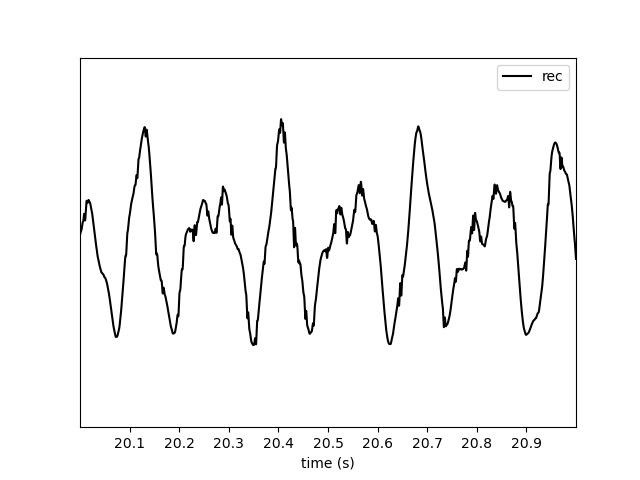

In [49]:
_ = sw.plot_traces(recording_filt, time_range=[20, 21])

A warning tells us that what we are doing is not optimized, since in order to get the requested traces the margin “overhead” is very large.

If we ask or plot longer snippets, the warning is not displayed.

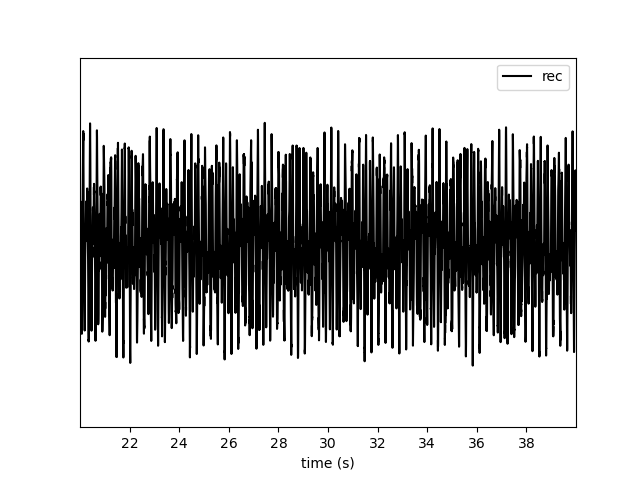

In [50]:
_ = sw.plot_traces(recording_filt, time_range=[20, 40])

## 4. Quantification and visualization of the artifacts

Let’s extract the traces and visualize the differences between chunking strategies. We’ll focus on the chunk boundaries where artifacts appear.

In [51]:
margins_ms = [100, 1000, 5000]  # in milliseconds
chunk_durations = ["1s", "10s", "30s"]  # in seconds

The best we can do is to save the full recording in one chunk. This will cause no artifacts and chunking effects, but in practice it’s not possible due to the duration and number of channels of most setups.

Since in this toy case we have a single channel 1-min recording, we can use this as “optimal”.

In [52]:
recording_optimal = recording_filt.save(
    folder="./cached/1ch/optimal",
    chunk_duration="1000s",
    progress_bar=False,
    overwrite=True
)

print(recording_optimal)

write_binary 
engine=process - n_jobs=1 - samples_per_chunk=30,000,000 - chunk_memory=114.44 MiB - total_memory=114.44 MiB - chunk_duration=1,000.00s (16.67 minutes)
BinaryFolderRecording: 1 channels - 30.0kHz - 1 segments - 1,800,000 samples 
                       60.00s (1.00 minutes) - float32 dtype - 6.87 MiB


/opt/anaconda3/envs/si_env/lib/python3.11/site-packages/spikeinterface/core/base.py:1012: UserWarning: The extractor is not serializable to file. The provenance will not be saved.
  warnings.warn("The extractor is not serializable to file. The provenance will not be saved.")


Now we can do the same wiht our various options

In [53]:
recordings_chunked = {}

for margin_ms in margins_ms:
    for chunk_duration in chunk_durations:
        print(f"Margin ms: {margin_ms}, Chunk duration: {chunk_duration}")
        t_start = time.perf_counter()
        recording_chunk = spre.bandpass_filter(
            recording_with_lfp,
            freq_min=1.0,
            freq_max=300.0,
            margin_ms=margin_ms,
            ignore_low_freq_error=True,
        )
        recording_chunk = recording_chunk.save(
            folder=f"./cached/1ch/margin_{margin_ms}_chunk_{chunk_duration}",
            chunk_duration=chunk_duration,
            verbose = False,
            progress_bar=False,
            overwrite=True
        )
        t_stop = time.perf_counter()
        result_dict = {"recording": recording_chunk, "time": t_stop - t_start}
        recordings_chunked[(margin_ms, chunk_duration)] = result_dict

/opt/anaconda3/envs/si_env/lib/python3.11/site-packages/spikeinterface/preprocessing/filter.py:518: UserWarning: The provided margin_ms (100 ms) is smaller than the recommended margin for the given freq_min (1.0 Hz). This may lead to artifacts at the edges of chunks during processing. Consider increasing the margin_ms to at least 5000.0 ms.
  warnings.warn(


Margin ms: 100, Chunk duration: 1s
Margin ms: 100, Chunk duration: 10s
Margin ms: 100, Chunk duration: 30s
Margin ms: 1000, Chunk duration: 1s
Margin ms: 1000, Chunk duration: 10s


/opt/anaconda3/envs/si_env/lib/python3.11/site-packages/spikeinterface/preprocessing/filter.py:518: UserWarning: The provided margin_ms (1000 ms) is smaller than the recommended margin for the given freq_min (1.0 Hz). This may lead to artifacts at the edges of chunks during processing. Consider increasing the margin_ms to at least 5000.0 ms.
  warnings.warn(


Margin ms: 1000, Chunk duration: 30s
Margin ms: 5000, Chunk duration: 1s
Margin ms: 5000, Chunk duration: 10s
Margin ms: 5000, Chunk duration: 30s


Let’s visualize the error for the “10s” chunks and different margins, centered around 30s (which is a chunk edge):

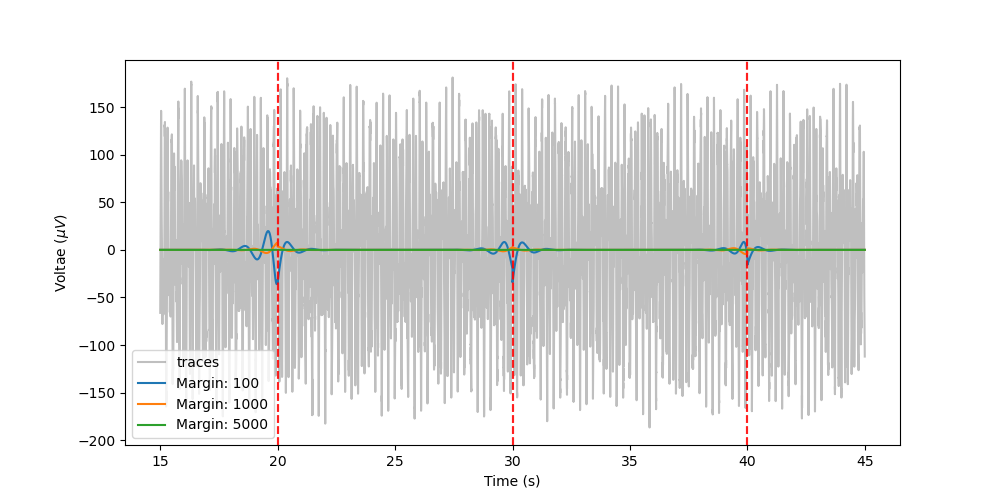

In [54]:
fig, ax = plt.subplots(figsize=(10, 5))
trace_plotted = False

start_time = 15 # seconds
end_time = 45 # seconds

start_frame = int(start_time * recording_optimal.sampling_frequency)
end_frame = int(end_time * recording_optimal.sampling_frequency)
timestamps = recording_optimal.get_times()[start_frame:end_frame]

for recording_key, recording_dict in recordings_chunked.items():
    recording_chunk = recording_dict["recording"]
    margin, chunk = recording_key
    # only plot 10s chunks
    if chunk != "10s":
        continue
    traces_opt = recording_optimal.get_traces(start_frame=start_frame, end_frame=end_frame)
    if not trace_plotted:
        ax.plot(timestamps, traces_opt, color='grey', label='traces', alpha=0.5)
        trace_plotted = True
    diff = recording_optimal - recording_chunk
    traces_diff = diff.get_traces(start_frame=start_frame, end_frame=end_frame)
    ax.plot(timestamps, traces_diff, label=f"Margin: {margin}")
    for chunk in [20, 30, 40]:
        ax.axvline(x=chunk, color='red', linestyle='--', alpha=0.5)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Voltae ($\\mu V$)")
_ = ax.legend()

From the plot, we can see that there is a very small error when the margin size is large (green), a larger error when the margin is smaller (orange) and a large error when the margin is small (blue). So we need large margins (compared to the chunk size) if we want accurate filtered.

The artifacts do not depend on chunk size, but for smaller chunk sizes, these artifacts will happen more often. In addition, the margin “overhead” will make processing slower. Let’s quantify these concepts by computing the overall absolute error with respect to the optimal case and processing time.

In [55]:
trace_plotted = False
traces_optimal = recording_optimal.get_traces()
data = {"margin": [], "chunk": [],"error": [], "time": []}

for recording_key, recording_dict in recordings_chunked.items():
    recording_chunk = recording_dict["recording"]
    time = recording_dict["time"]
    margin, chunk = recording_key
    traces_chunk = recording_chunk.get_traces()
    error = np.sum(np.abs(traces_optimal - traces_chunk))
    data["margin"].append(margin)
    data["chunk"].append(chunk)
    data["error"].append(error)
    data["time"].append(time)

df = pd.DataFrame(data)

Now let’s visualize the error and processing time for different margin and chunk size combinations

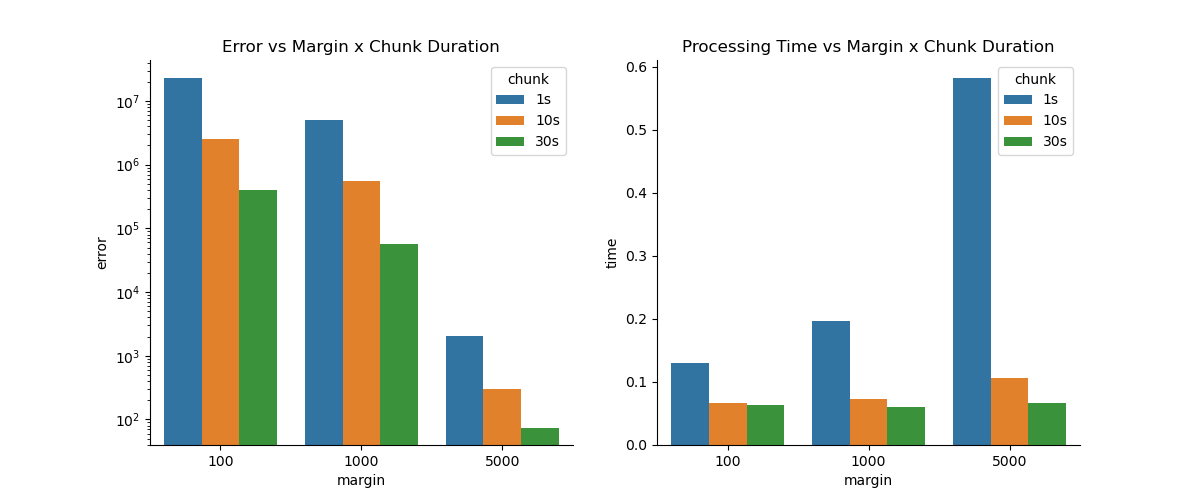

In [56]:
fig, axs = plt.subplots(ncols=2, figsize=(12, 5))
sns.barplot(data = data, x="margin", y="error", hue="chunk", ax=axs[0])
axs[0].set_yscale("log")
axs[0].set_title("Error vs Margin x Chunk Duration")

sns.barplot(data = data, x="margin", y="time", hue="chunk", ax=axs[1])
axs[1].set_title("Processing Time vs Margin x Chunk Duration")

sns.despine(fig)

/opt/anaconda3/envs/si_env/lib/python3.11/site-packages/ipympl/backend_nbagg.py:335: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  self.figure.savefig(buf, format='png', dpi='figure')


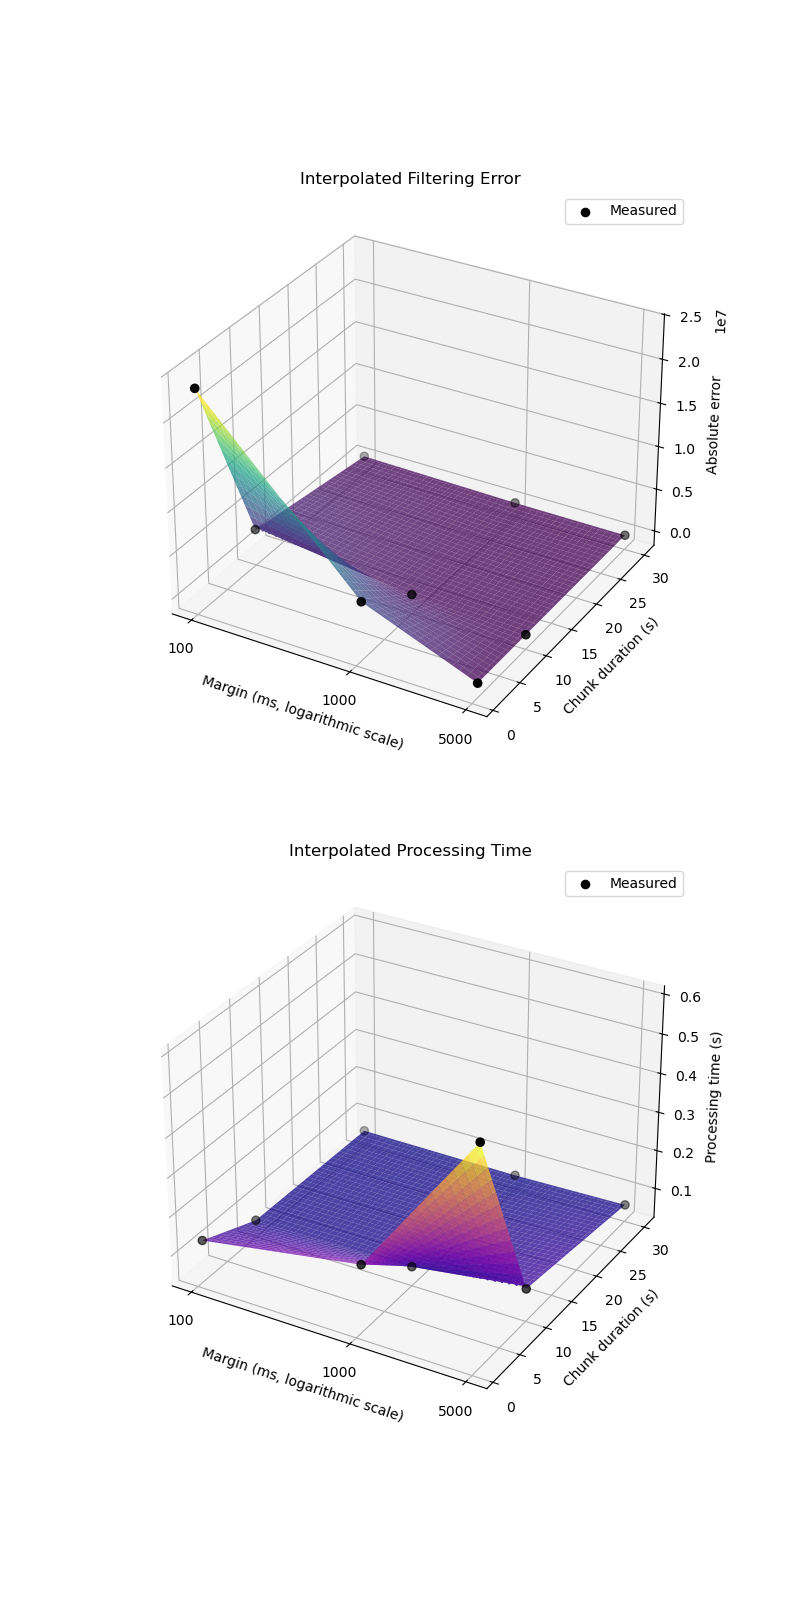

In [57]:
from scipy.interpolate import RegularGridInterpolator

# Convert the categorical chunk labels to numeric seconds.
surface_df = df.copy()
surface_df["chunk_seconds"] = surface_df["chunk"].str.rstrip("s").astype(float)

margin_values = np.sort(surface_df["margin"].unique())
chunk_values = np.sort(surface_df["chunk_seconds"].unique())
log_margin_values = np.log10(margin_values)
log_margin_grid = np.linspace(log_margin_values.min(), log_margin_values.max(), 80)
chunk_grid = np.linspace(chunk_values.min(), chunk_values.max(), 80)
log_margin_mesh, chunk_mesh = np.meshgrid(log_margin_grid, chunk_grid)

def interpolate_metric(metric):
    metric_grid = surface_df.pivot(
        index="chunk_seconds", columns="margin", values=metric
    ).loc[chunk_values, margin_values].to_numpy()
    interpolator = RegularGridInterpolator(
        (chunk_values, log_margin_values),
        metric_grid,
        bounds_error=False,
    )
    query_points = np.column_stack(
        [chunk_mesh.ravel(), log_margin_mesh.ravel()]
    )
    return interpolator(query_points).reshape(chunk_mesh.shape)

error_surface = interpolate_metric("error")
time_surface = interpolate_metric("time")

fig = plt.figure(figsize=(8, 16), constrained_layout=True)

ax_error = fig.add_subplot(211, projection="3d")
ax_error.plot_surface(
    log_margin_mesh, chunk_mesh, error_surface,
    cmap="viridis", alpha=0.75, edgecolor="none"
 )
ax_error.scatter(
    np.log10(surface_df["margin"]),
    surface_df["chunk_seconds"],
    surface_df["error"],
    color="black", s=35, label="Measured"
 )
ax_error.set_title("Interpolated Filtering Error")
ax_error.set_xlabel("Margin (ms, logarithmic scale)")
ax_error.set_ylabel("Chunk duration (s)")
ax_error.set_zlabel("Absolute error")
ax_error.set_xticks(log_margin_values)
ax_error.set_xticklabels([str(value) for value in margin_values])
ax_error.legend()

ax_time = fig.add_subplot(212, projection="3d")
ax_time.plot_surface(
    log_margin_mesh, chunk_mesh, time_surface,
    cmap="plasma", alpha=0.75, edgecolor="none"
 )
ax_time.scatter(
    np.log10(surface_df["margin"]),
    surface_df["chunk_seconds"],
    surface_df["time"],
    color="black", s=35, label="Measured"
 )
ax_time.set_title("Interpolated Processing Time")
ax_time.set_xlabel("Margin (ms, logarithmic scale)")
ax_time.set_ylabel("Chunk duration (s)")
ax_time.set_zlabel("Processing time (s)")
ax_time.set_xticks(log_margin_values)
ax_time.set_xticklabels([str(value) for value in margin_values])
ax_time.legend()

## Summary
1. **Low-frequency filters require special care**: Filters with low cutoff frequencies (< 10 Hz) have long impulse responses that require large margins to avoid edge artifacts.

2. **Chunking artifacts are real**: When processing data in chunks, insufficient margins lead to visible discontinuities and errors at chunk boundaries.

3. **The solution: large chunks and large**: For LFP extraction (1-300 Hz), use: - Chunk size: 30-60 seconds - Margin size: 5 seconds (for 1 Hz highpass) (use defaults!) - This is less memory-efficient but more accurate

4. **Downsample after filtering**: After bandpass filtering, downsample to reduce data size (e.g., to 1-2.5 kHz for 300 Hz max frequency).

5. **Trade-offs**: There’s always a trade-off between computational efficiency (smaller chunks, less memory) and accuracy (larger chunks, fewer artifacts). For LFP analysis, accuracy should take priority.

**When processing your own data:**

* If you have memory constraints, use the largest chunk size your system can handle

* Always verify your filtering parameters on a small test segment first

* Consider the lowest frequency component you want to preserve when setting margins

* Save the processed LFP data to disk to avoid recomputing